# Student Performance Analysis
## Can we predict whether a student will pass?

This notebook explores the factors that influence student performance
and builds a machine learning model to predict pass/fail outcomes.

**Dataset:** 500 students, 10 features
**Key Question:** Which factors most strongly predict academic success?

## 2. Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

## 3. Data Loading & First Look

The dataset contains 500 students with 10 features including study habits,
attendance, and academic scores. Initial inspection shows no obvious data issues.

In [1]:
from google.colab import files
uploaded = files.upload()

Saving student_performance.csv to student_performance.csv


In [4]:
df = pd.read_csv('student_performance.csv')
df.head()

,student_id,gender,age,study_hours_per_week,attendance_rate,parent_education,internet_access,extracurricular,previous_score,final_score,passed
0,STU0001,Male,15,25,63.8,Bachelor,Yes,Yes,41,67,Yes
1,STU0002,Female,15,2,54.7,Bachelor,Yes,Yes,83,28,No
2,STU0003,Female,19,10,90.5,High School,Yes,No,73,49,No
3,STU0004,Male,16,26,66.8,High School,No,Yes,75,70,Yes
4,STU0005,Female,15,25,73.0,High School,No,Yes,67,77,Yes


In [5]:
df.describe()

,age,study_hours_per_week,attendance_rate,previous_score,final_score
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,16.978000,15.312000,76.380600,62.986000,55.980000
std,1.434445,8.568167,13.817681,18.937451,15.373754
min,15.000000,2.000000,50.200000,30.000000,20.000000
25%,16.000000,8.000000,64.475000,46.000000,45.000000
50%,17.000000,15.000000,76.500000,64.000000,56.000000
75%,18.000000,23.000000,88.525000,79.000000,68.000000
max,19.000000,30.000000,100.000000,95.000000,95.000000


In [6]:
df.shape

(500, 11)

## 4. Data Cleaning

In [8]:
df.isnull().sum()

,0
student_id,0
gender,0
age,0
study_hours_per_week,0
attendance_rate,0
parent_education,117
internet_access,0
extracurricular,0
previous_score,0
final_score,0


The `parent_education` column has 117 missing values (23% of data).
Since this is a high proportion and the column is not critical for our analysis,
we will drop it.

In [9]:
df = df.drop(columns=['parent_education'])
df.dtypes

,0
student_id,object
gender,object
age,int64
study_hours_per_week,int64
attendance_rate,float64
internet_access,object
extracurricular,object
previous_score,int64
final_score,int64
passed,object


In [10]:
numeric_cols = ['age', 'study_hours_per_week', 'attendance_rate', 'previous_score', 'final_score']

Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

outliers = ((df[numeric_cols] < (Q1 - 1.5 * IQR)) | (df[numeric_cols] > (Q3 + 1.5 * IQR)))
outliers.sum()

,0
age,0
study_hours_per_week,0
attendance_rate,0
previous_score,0
final_score,0


No outliers were detected using the IQR method.
The dataset is clean and ready for analysis.

## 5. Exploratory Data Analysis

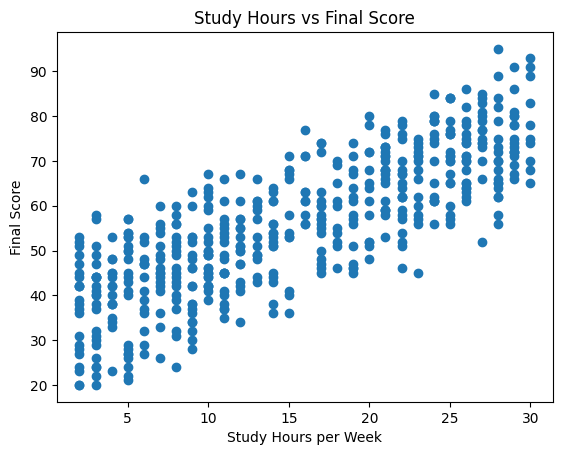

In [12]:
plt.scatter(df['study_hours_per_week'], df['final_score'])
plt.xlabel('Study Hours per Week')
plt.ylabel('Final Score')
plt.title('Study Hours vs Final Score')
plt.show()

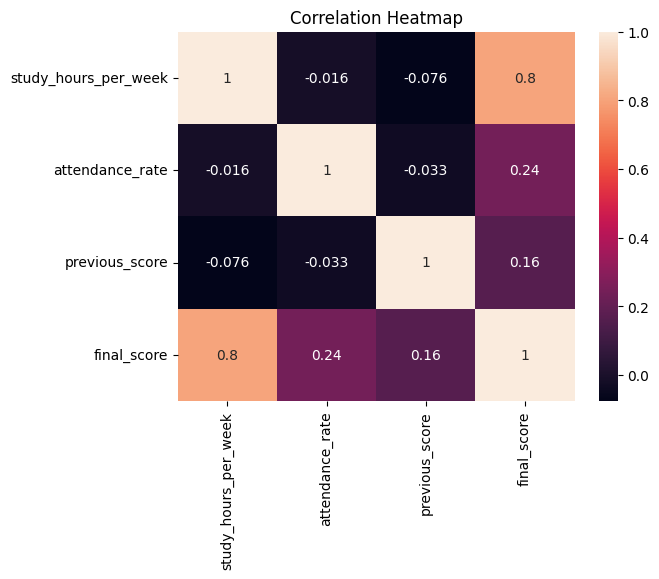

In [13]:
sns.heatmap(df[['study_hours_per_week', 'attendance_rate', 'previous_score', 'final_score']].corr(), annot=True)
plt.title('Correlation Heatmap')
plt.show()

Study hours per week shows the strongest correlation with final score (r = 0.80),
suggesting it is the most important predictor of academic performance.
Attendance rate and previous score show weaker correlations (0.24 and 0.16).

## 6. Machine Learning Models

We compare three models to predict whether a student will pass:
- Logistic Regression
- Decision Tree
- Random Forest

In [14]:
df['passed_numeric'] = (df['passed'] == 'Yes').astype(int)

X = df[['study_hours_per_week', 'attendance_rate', 'previous_score']]
y = df['passed_numeric']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### 6.1 Logistic Regression

In [15]:
model_lr = LogisticRegression()
model_lr.fit(X_train, y_train)
print("Logistic Regression Accuracy:", model_lr.score(X_test, y_test))

Logistic Regression Accuracy: 0.87


In [16]:
y_pred = model_lr.predict(X_test)
confusion_matrix(y_test, y_pred)

array([[25, 11],
       [ 2, 62]])

The model misclassified 13 students. Most critical: 11 students were
predicted to pass but actually failed — these are at-risk students
the model missed.

### 6.2 Decision Tree

In [17]:
# Without max_depth - overfitting
model_dt = DecisionTreeClassifier(random_state=42)
model_dt.fit(X_train, y_train)
print("Train:", model_dt.score(X_train, y_train))
print("Test:", model_dt.score(X_test, y_test))

# With max_depth=3 - balanced
model_dt3 = DecisionTreeClassifier(max_depth=3, random_state=42)
model_dt3.fit(X_train, y_train)
print("Train (max_depth=3):", model_dt3.score(X_train, y_train))
print("Test (max_depth=3):", model_dt3.score(X_test, y_test))

Train: 1.0
Test: 0.78
Train (max_depth=3): 0.84
Test (max_depth=3): 0.84


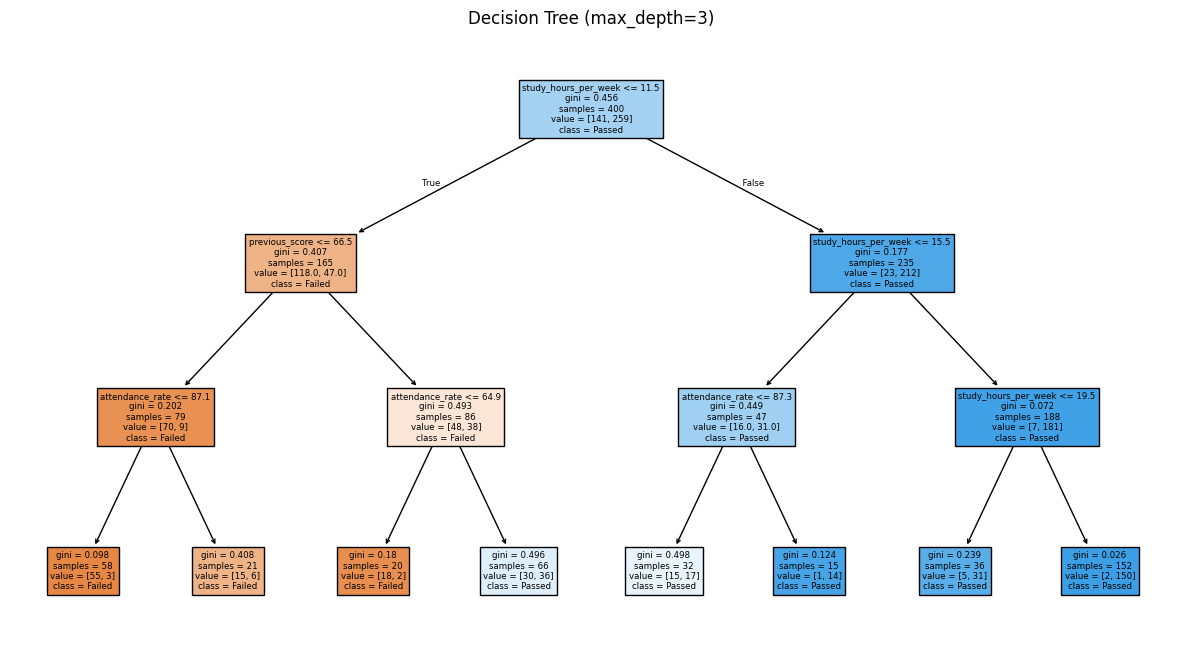

In [18]:
plt.figure(figsize=(15,8))
plot_tree(model_dt3, feature_names=['study_hours_per_week', 'attendance_rate', 'previous_score'], class_names=['Failed', 'Passed'], filled=True)
plt.title('Decision Tree (max_depth=3)')
plt.show()

Without depth limit, the Decision Tree achieves 100% train accuracy but
only 80% test accuracy — a clear sign of overfitting. Setting max_depth=3
balances train (84%) and test (84%) accuracy, creating a more generalizable model.

### 6.3 Random Forest

In [19]:
model_rf = RandomForestClassifier(max_depth=3, random_state=42)
model_rf.fit(X_train, y_train)
print("Train:", model_rf.score(X_train, y_train))
print("Test:", model_rf.score(X_test, y_test))

Train: 0.8725
Test: 0.86


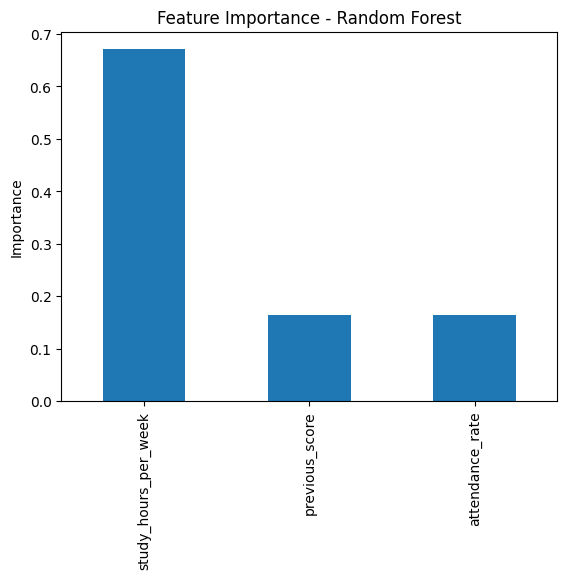

In [20]:
pd.Series(model_rf.feature_importances_, index=['study_hours_per_week', 'attendance_rate', 'previous_score']).sort_values(ascending=False).plot(kind='bar')
plt.title('Feature Importance - Random Forest')
plt.ylabel('Importance')
plt.show()

Random Forest confirms our earlier findings: study_hours_per_week is by far
the most important predictor (67%), followed by previous_score (17%)
and attendance_rate (16%).

## 7. Model Comparison & Conclusion

In [21]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Test Accuracy': [model_lr.score(X_test, y_test),
                      model_dt3.score(X_test, y_test),
                      model_rf.score(X_test, y_test)]
})

results.sort_values('Test Accuracy', ascending=False)

,Model,Test Accuracy
0,Logistic Regression,0.87
2,Random Forest,0.86
1,Decision Tree,0.84


## Conclusion

**Key Findings:**
- Study hours per week is the strongest predictor of academic success (correlation: 0.80, feature importance: 67%)
- Attendance rate and previous score have weaker but positive effects
- All three models confirm the same pattern

**Best Model:** Logistic Regression (87% accuracy) — simpler models can outperform complex ones

**Practical Implication:** Students who study more than 15 hours per week
are significantly more likely to pass. Interventions should focus on
increasing study time rather than attendance alone.